<a href="https://colab.research.google.com/github/kosaremazahery/Machine-Learning-Project--COMPAS/blob/main/compas_fairness_module_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fairness-Aware Recidivism Classification on COMPAS
**Machine Learning Assignment**

We train a classifier to predict two-year recidivism on the COMPAS dataset, then audit
its predictions for fairness across racial groups and test a simple mitigation.
Data source: ProPublica, *Machine Bias* (2016) — https://github.com/propublica/compas-analysis


## 1. Setup and data loading
We load the data straight from ProPublica's repository so the notebook runs anywhere with no local files.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42  # fixed so every run is reproducible

URL = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw = pd.read_csv(URL)
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


## 2. Data cleaning (ProPublica's filters)
The raw file contains rows that ProPublica themselves discard as unreliable. We apply the
same four filters from their methodology before doing anything else:
- the arrest and the COMPAS screening must be within 30 days of each other,
- rows with no matching COMPAS case (`is_recid == -1`) are dropped,
- ordinary traffic offences (`c_charge_degree == 'O'`) are dropped,
- rows with a missing risk category (`score_text == 'N/A'`) are dropped.

In [ ]:
df = raw[
    (raw["days_b_screening_arrest"] <= 30) &
    (raw["days_b_screening_arrest"] >= -30) &
    (raw["is_recid"] != -1) &
    (raw["c_charge_degree"] != "O") &
    (raw["score_text"] != "N/A")
].copy()
print("Shape after cleaning:", df.shape)

Shape after cleaning: (6172, 53)


## 3. Feature selection and the COMPAS label
We keep the columns we need, and turn COMPAS's 1–10 risk score into a binary High/Low prediction using the standard cutoff of 5, so we can compare it to our own model later.

In [ ]:
cols = [
    "race", "sex", "age", "priors_count","c_charge_degree",
    "decile_score", "score_text",
    "two_year_recid"
]
df = df[cols]

df["pred"] = (df["decile_score"] >= 5).astype(int)  # COMPAS's own High(1)/Low(0) decision
df.head()

,race,sex,age,priors_count,c_charge_degree,decile_score,score_text,two_year_recid,pred
0,Other,Male,69,0,F,1,Low,0,0
1,African-American,Male,34,0,F,3,Low,1,0
2,African-American,Male,24,4,F,4,Low,1,0
5,Other,Male,44,0,M,1,Low,0,0
6,Caucasian,Male,41,14,F,6,Medium,1,1


**Feature selection rationale.** The raw dataset contains 53 columns, but most are unusable as model inputs. We exclude them on three principled grounds. First, *leakage*: columns such as `is_recid`, the `r_*` and `vr_*` re-offense records, and the jail/custody dates are recorded at or after the outcome we are trying to predict, so using them would let the model "cheat." Second, *circularity*: COMPAS's own scores (`decile_score`, `score_text`, and the violence-risk `v_*` fields) are the very outputs we want to audit, so we exclude them as inputs and keep `decile_score`/`score_text` only to build the COMPAS baseline. Third, *non-informative* columns — identifiers, names, dates, and free-text charge descriptions — carry no generalizable signal and raise privacy concerns. This leaves a small set of legitimate, screening-time attributes: `age`, `priors_count`, `sex`, `C_charge_degree` and `race`. We deliberately keep this feature set minimal and interpretable, matching the features used in COMPAS's public analyses; `race` is retained not as an ordinary predictor but as the sensitive attribute required for the fairness analysis.

## 4. Data understanding

We move from the general to the specific: first profile the sample as a whole, then look at how the
outcome varies across groups, then ask *why* those differences appear, and finally cross the
attributes to see who the score actually singles out.

### 4a. Profiling the sample
Structure and types, summary statistics, missing values, target balance, and the distribution of each
feature — one variable at a time.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   race             6172 non-null   object
 1   sex              6172 non-null   object
 2   age              6172 non-null   int64 
 3   priors_count     6172 non-null   int64 
 4   c_charge_degree  6172 non-null   object
 5   decile_score     6172 non-null   int64 
 6   score_text       6172 non-null   object
 7   two_year_recid   6172 non-null   int64 
 8   pred             6172 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 482.2+ KB


In [ ]:
df.describe(include="all")

,race,sex,age,priors_count,c_charge_degree,decile_score,score_text,two_year_recid,pred
count,6172,6172,6172.000000,6172.000000,6172,6172.000000,6172,6172.000000,6172.000000
unique,6,2,NaN,NaN,2,NaN,3,NaN,NaN
top,African-American,Male,NaN,NaN,F,NaN,Low,NaN,NaN
freq,3175,4997,NaN,NaN,3970,NaN,3421,NaN,NaN
mean,NaN,NaN,34.534511,3.246436,NaN,4.418503,NaN,0.455120,0.445723
std,NaN,NaN,11.730938,4.743770,NaN,2.839463,NaN,0.498022,0.497086
min,NaN,NaN,18.000000,0.000000,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,NaN,25.000000,0.000000,NaN,2.000000,NaN,0.000000,0.000000
50%,NaN,NaN,31.000000,1.000000,NaN,4.000000,NaN,0.000000,0.000000
75%,NaN,NaN,42.000000,4.000000,NaN,7.000000,NaN,1.000000,1.000000


**Observations from the summary statistics.**

- **Completeness.** Every column reports a count of 6,172, so there are no missing values after cleaning. No imputation is required.
- **Sample composition.** The dataset is ~51% African-American (3,175) and ~81% male (4,997). The two largest racial groups are well represented, but the sample is far from demographically balanced, which limits how far conclusions generalise.
- **`priors_count` is heavily right-skewed** — mean 3.25 against a median of 1, with a maximum of 38. Most defendants have few or no priors, while a small tail has many. Tree-based models split on thresholds, so they handle this skew without scaling; a distance- or gradient-based model would benefit from a transformation.
- **`age` skews young** — median 31, mean 34.5, range 18–96, with 75% of defendants under 42. A young population, consistent with the age–crime curve, which suggests `age` should carry predictive signal.
- **`decile_score`** is centred at a mean of 4.4 (median 4), so the High/Low cutoff at 5 splits the sample roughly down the middle rather than producing a lopsided class.
- **Target balance.** `two_year_recid` has a mean of 0.455, i.e. 45.5% of defendants re-offended within two years. The classes are close to balanced, so accuracy is a reasonable headline metric and stratified splitting is appropriate.
- **Aggregate agreement between COMPAS and reality.** COMPAS flags 44.6% of defendants as high risk (`pred` mean 0.446) against an actual recidivism rate of 45.5%. At the population level the tool is therefore well calibrated in volume — it predicts roughly as many positives as truly occur. This is an important caveat for the evaluation that follows: aggregate agreement of this kind can mask systematic differences in *which* individuals the errors fall on, so overall metrics alone are not sufficient to assess the model.

Missing values per column:

In [ ]:
df.isna().sum()

race               0
sex                0
age                0
priors_count       0
c_charge_degree    0
decile_score       0
score_text         0
two_year_recid     0
pred               0
dtype: int64

Is `two_year_recid` roughly even, or skewed? This decides whether accuracy alone is a fair metric and motivates `stratify` later.

two_year_recid
0    0.545
1    0.455
Name: proportion, dtype: float64


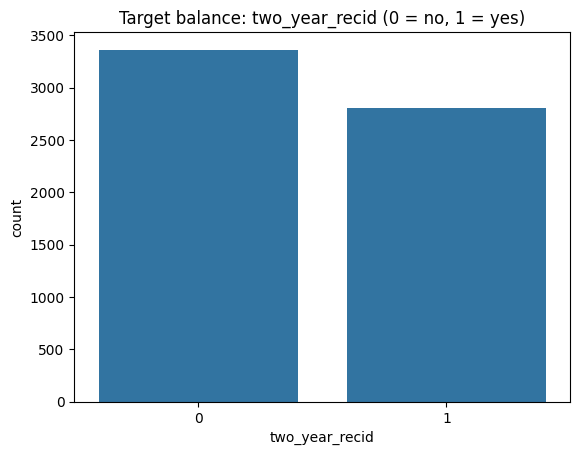

In [ ]:
print(df["two_year_recid"].value_counts(normalize=True).round(3))
sns.countplot(data=df, x="two_year_recid")
plt.title("Target balance: two_year_recid (0 = no, 1 = yes)")
plt.show()

Univariate distributions of the numeric features:

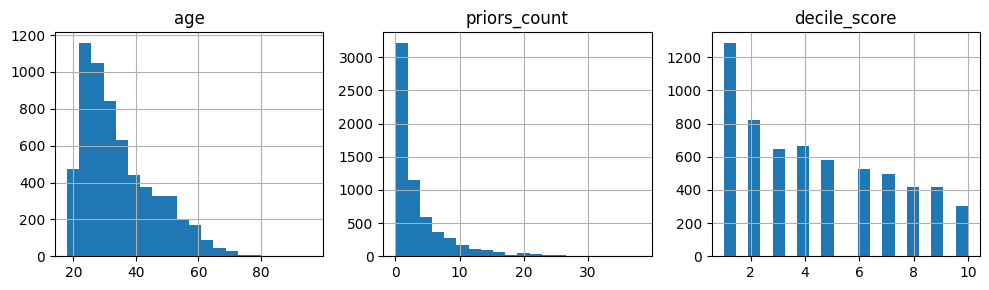

In [ ]:
df[["age", "priors_count", "decile_score"]].hist(figsize=(10,3), bins=20, layout=(1,3))
plt.tight_layout()
plt.show()

1- here, Based on this distributation, I asked LLM(Claude) to test to see if there is any transformation needede for the skewed data to apply later in modelling and model selection, and this is the answer:

**Modelling notes from the distributions.**

- **Skew in `priors_count`.** The feature is heavily right-skewed (mean 3.2, median 1, max 38). This matters for linear models, which assume a constant effect per additional prior — an assumption the long tail violates. Applying `log1p` to the numeric features raises Logistic Regression from AUC 0.731 to 0.737; the tree-based models are unaffected, since they split on thresholds and are invariant to monotone transformations.
- **Scaling is not required.** Neither Logistic Regression nor Random Forest changes measurably when `StandardScaler` is applied (AUC identical to three decimals). Trees are scale-invariant, and logistic regression simply rescales its coefficients. We therefore omit scaling rather than adding it by reflex.
- **No outlier removal.** The high tail of `priors_count` consists of real, informative records — defendants in the top decile re-offend at 75.7% — so it is signal, not noise.
- **Model choice has little effect.** Every model tested lands in the range 0.68–0.70 accuracy and 0.71–0.74 AUC. This suggests the ceiling is imposed by the data (few features, an inherently noisy outcome) rather than by model capacity — consistent with published findings that COMPAS's own performance is matched by very simple models.

Counts and proportions for the categorical features:

In [ ]:
for col in ["sex", "score_text", "c_charge_degree"]:
    counts = df[col].value_counts()
    summary = pd.DataFrame({
        "count":      counts,
        "percent":    (counts / len(df) * 100).round(1),
        "recid_rate": df.groupby(col)["two_year_recid"].mean().round(3),
    })
    print(col, "\n", summary, "\n")

sex 
         count  percent  recid_rate
sex                               
Female   1175     19.0       0.351
Male     4997     81.0       0.479 

score_text 
             count  percent  recid_rate
score_text                            
High         1144     18.5       0.740
Low          3421     55.4       0.315
Medium       1607     26.0       0.551 

c_charge_degree 
                  count  percent  recid_rate
c_charge_degree                            
F                 3970     64.3       0.500
M                 2202     35.7       0.375 



**Observations on the categorical features.**

- **`sex` is heavily imbalanced** — 81% male (4,997) against 19% female (1,175) — and predictive: men re-offend at 47.9% against 35.1% for women. Any sex-disaggregated result therefore rests on a much smaller female sample.
- **`c_charge_degree` skews toward felonies** — 64% F against 36% M — and also carries signal: 50.0% of felony defendants re-offend against 37.5% of misdemeanour defendants.
- **`score_text` is a binned version of `decile_score`**, not independent information: Low corresponds exactly to deciles 1–4, Medium to 5–7, High to 8–10. It is redundant as a feature and is kept only for interpretation.
- **The risk categories are meaningfully ordered.** Recidivism rises monotonically across them — 31.5% (Low), 55.1% (Medium), 74.0% (High) — so COMPAS does separate risk levels in aggregate. The question is not whether the tool has predictive power, but whether its errors fall equally across groups.
- **Interpreting the `decile_score >= 5` cutoff.** It maps exactly onto {Medium, High}, following ProPublica's convention. The positive class therefore means "not low risk" rather than "high risk", which is why 44.6% of defendants are flagged; using `score_text == "High"` alone would flag only 18.5%.

**Where this leaves us.** These are *marginal* observations — one variable at a time. They tell us the
sample is predominantly male, predominantly charged with felonies, and roughly half African-American,
but nothing about how those attributes interact. The rest of this section builds from there.

### 4b. Group differences
The first question the marginals cannot answer: does the outcome — and does COMPAS's score — look the
same across racial groups?

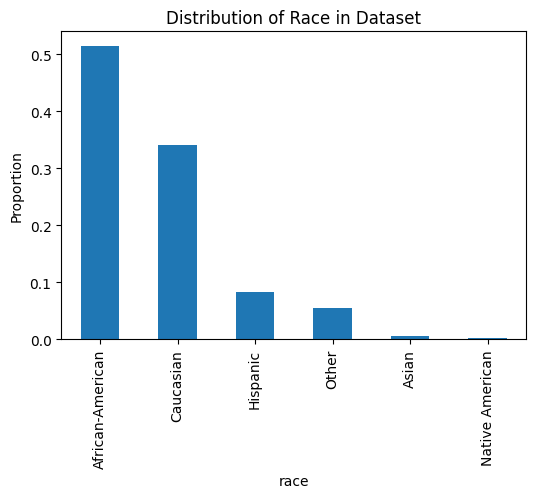

In [ ]:
df["race"].value_counts(normalize=True).plot(kind="bar", figsize=(6,4))
plt.title("Distribution of Race in Dataset")
plt.ylabel("Proportion")
plt.show()

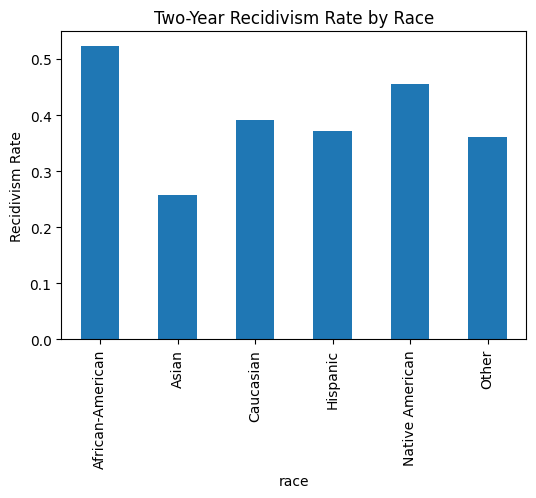

In [ ]:
df.groupby("race")["two_year_recid"].mean().plot(kind="bar", figsize=(6,4))
plt.title("Two-Year Recidivism Rate by Race")
plt.ylabel("Recidivism Rate")
plt.show()

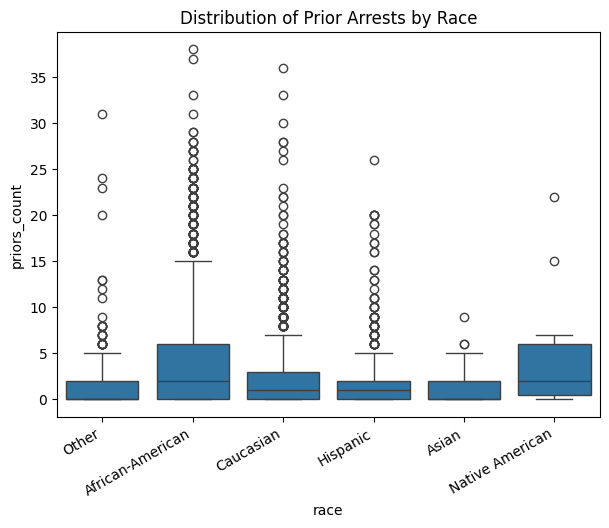

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="race", y="priors_count")
plt.title("Distribution of Prior Arrests by Race")
plt.xticks(rotation=30, ha="right")
plt.show()

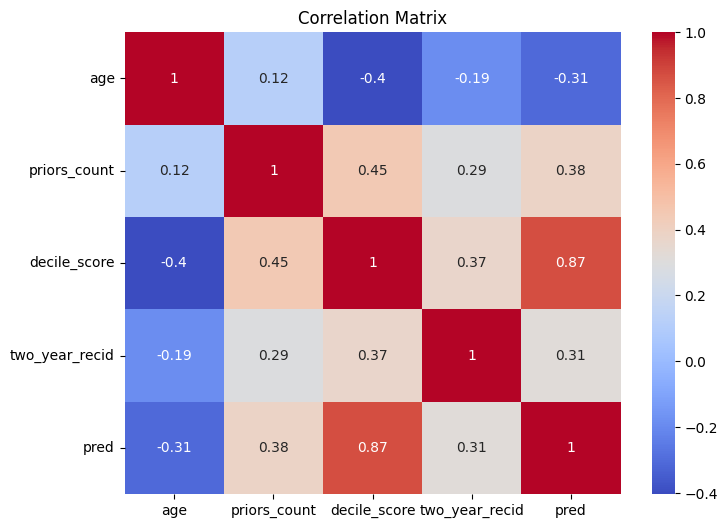

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

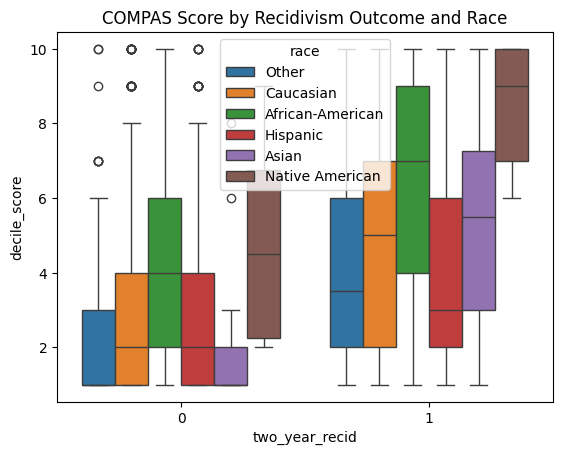

In [ ]:
sns.boxplot(data=df, x="two_year_recid", y="decile_score", hue="race")
plt.title("COMPAS Score by Recidivism Outcome and Race")
plt.show()

**Observations.** Recidivism rates differ across groups, but so does `priors_count` — and the final
plot shows COMPAS assigns systematically higher scores to African-American defendants *even at the same
outcome*. Two questions follow. First: `priors_count` is our strongest feature and it differs sharply by
race — is it carrying racial information into the model? Second: is the score responding to race itself,
or to some combination of attributes? We take them in turn.

### 4c. Is `priors_count` a proxy for race?

`priors_count` is the strongest single predictor in this dataset, and the boxplot above shows it is
distributed unevenly across groups. If it encodes racial information, then removing `race` from the
model will not remove race *from the model's decisions* — the signal can be reconstructed through the
proxy. We test this by isolating the high-priors tail (the top decile) and examining its composition.

In [ ]:
threshold = df["priors_count"].quantile(0.90)
df["high_priors"] = df["priors_count"] >= threshold

print(f"High-priors threshold (90th percentile): {threshold:.0f} priors")
print(f"Group size: {df['high_priors'].sum()} defendants "
      f"({df['high_priors'].mean()*100:.1f}% of the sample)")
print(f"Recidivism rate — high-priors: {df.loc[df.high_priors,'two_year_recid'].mean():.3f} "
      f"| everyone else: {df.loc[~df.high_priors,'two_year_recid'].mean():.3f}")

High-priors threshold (90th percentile): 9 priors
Group size: 709 defendants (11.5% of the sample)
Recidivism rate — high-priors: 0.757 | everyone else: 0.416


In [ ]:
MIN_N = 100                       # exclude groups too small to interpret
counts = df["race"].value_counts()
groups = counts[counts >= MIN_N].index.tolist()

comp = pd.DataFrame({
    "overall_share":     df["race"].value_counts(normalize=True) * 100,
    "high_priors_share": df.loc[df.high_priors, "race"].value_counts(normalize=True) * 100,
    "rate_in_tail":      df.groupby("race")["high_priors"].mean() * 100,
    "median_priors":     df.groupby("race")["priors_count"].median(),
    "n":                 df["race"].value_counts(),
}).loc[groups]

comp.round(1)

,overall_share,high_priors_share,rate_in_tail,median_priors,n
race,,,,,
African-American,51.4,75.2,16.8,2.0,3175
Caucasian,34.1,18.8,6.3,1.0,2103
Hispanic,8.2,4.4,6.1,1.0,509
Other,5.6,1.3,2.6,0.0,343


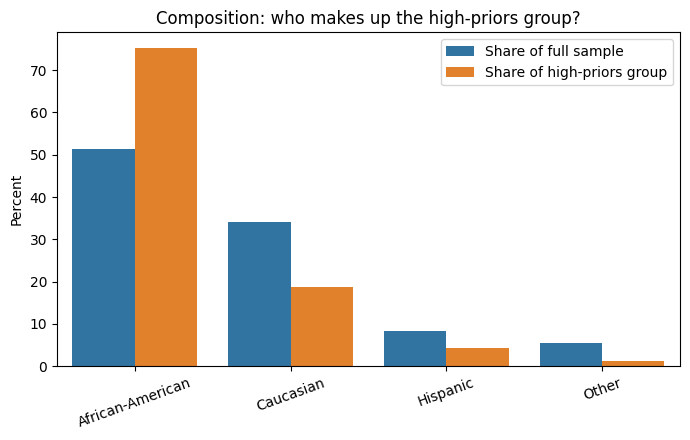

In [ ]:
plot_df = comp.reset_index(names="race")

melted = plot_df.melt(id_vars="race",
                      value_vars=["overall_share", "high_priors_share"],
                      var_name="measure", value_name="percent")
melted["measure"] = melted["measure"].map({
    "overall_share": "Share of full sample",
    "high_priors_share": "Share of high-priors group"})

plt.figure(figsize=(7, 4.5))
sns.barplot(data=melted, x="race", y="percent", hue="measure")
plt.title("Composition: who makes up the high-priors group?")
plt.ylabel("Percent"); plt.xlabel("")
plt.xticks(rotation=20); plt.legend(title="")
plt.tight_layout()
plt.show()

**Observations.**

- The tail is defined as `priors_count >= 9` (the 90th percentile): 709 defendants, 11.5% of the sample.
- **It is strongly predictive.** Defendants in the tail re-offend at 75.7% against 41.6% for everyone else — which is why `priors_count` dominates the feature importances later.
- **It is also strongly race-correlated.** African-American defendants are 51% of the sample but 75.2% of the tail. Controlling for group size, 16.8% of African-American defendants fall in the tail against 6.3% of Caucasian defendants — a ratio of roughly 2.7×.
- **Consequence for modelling.** `priors_count` therefore acts as a **proxy**: it carries racial information even when `race` is not supplied. A model trained without `race` can still reconstruct much of the group difference through this feature. This prediction is tested directly in Section 8.

**Caveat.** `priors_count` records prior *arrests*, which reflect policing and enforcement patterns — where
patrols are concentrated, who is stopped and charged — not offending behaviour directly. This describes a
disparity in the criminal-justice record, not a difference between groups of people, and every downstream
conclusion inherits that limitation.

**Groups shown.** Only groups with at least 100 defendants. Asian (n=31) and Native American (n=11) are
omitted: Native American defendants show the highest tail rate in the raw data (18.2%), but at n=11 that
is not interpretable.

### 4d. From marginals to a profile

The profiling in 4a told us the sample is mostly male and mostly felony charges; 4b and 4c showed race
runs through both the outcome and the strongest feature. What it has not told us is how the attributes
*combine*. We now cross them.

> **Hypothesis.** The COMPAS score is not applied uniformly. Crossing race, sex, and charge severity, we
> expect to find a specific combination of attributes flagged as high-risk more often than its actual
> recidivism rate justifies.

A caution before testing it: a group being *large* does not by itself imply bias — more data on a group
usually produces *better* predictions for it, not worse. The claim must be tested at the level of rates
*within* cells, not raw counts.

In [ ]:
subset = df[df["race"].isin(["African-American", "Caucasian"])].copy()

print("Cell sizes (race x sex x charge):")
print(pd.crosstab([subset["race"], subset["sex"]], subset["c_charge_degree"], margins=True), "\n")

rows = []
for (r, s, c), g in subset.groupby(["race", "sex", "c_charge_degree"], observed=True):
    if len(g) < 50:                                  # skip cells too small to interpret
        continue
    not_recid = g[g["two_year_recid"] == 0]
    rows.append({
        "race": r, "sex": s, "charge": c, "n": len(g),
        "flag_rate":    g["pred"].mean(),            # how often COMPAS says high-risk
        "actual_recid": g["two_year_recid"].mean(),  # how often they actually re-offend
        "FPR":          not_recid["pred"].mean(),    # wrongly flagged among non-reoffenders
    })

cells = pd.DataFrame(rows)
cells["over_flag"] = cells["flag_rate"] - cells["actual_recid"]
cells.sort_values("FPR", ascending=False).round(3)

Cell sizes (race x sex x charge):
c_charge_degree             F     M   All
race             sex                     
African-American Female   360   189   549
                 Male    1836   790  2626
Caucasian        Female   249   233   482
                 Male     995   626  1621
All                      3440  1838  5278 



,race,sex,charge,n,flag_rate,actual_recid,FPR,over_flag
2,African-American,Male,F,1836,0.627,0.582,0.451,0.046
0,African-American,Female,F,360,0.561,0.414,0.436,0.147
3,African-American,Male,M,790,0.513,0.494,0.410,0.019
4,Caucasian,Female,F,249,0.478,0.442,0.381,0.036
1,African-American,Female,M,189,0.370,0.286,0.289,0.085
6,Caucasian,Male,F,995,0.378,0.433,0.232,-0.055
5,Caucasian,Female,M,233,0.279,0.258,0.214,0.021
7,Caucasian,Male,M,626,0.217,0.353,0.151,-0.136


Now hold sex and charge fixed at the modal profile (male, felony) and let age vary:

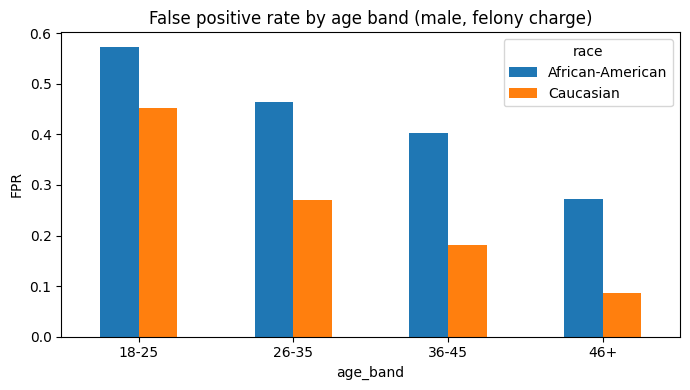

,race,age_band,n,FPR,actual_recid
0,African-American,18-25,606,0.573,0.640
1,African-American,26-35,720,0.463,0.622
2,African-American,36-45,270,0.403,0.448
3,African-American,46+,240,0.271,0.462
4,Caucasian,18-25,233,0.452,0.506
5,Caucasian,26-35,309,0.271,0.498
6,Caucasian,36-45,206,0.180,0.408
7,Caucasian,46+,247,0.087,0.304


In [ ]:
subset["age_band"] = pd.cut(subset["age"], [17, 25, 35, 45, 100],
                            labels=["18-25", "26-35", "36-45", "46+"])
modal = subset[(subset["sex"] == "Male") & (subset["c_charge_degree"] == "F")]

rows = []
for (r, a), g in modal.groupby(["race", "age_band"], observed=True):
    not_recid = g[g["two_year_recid"] == 0]
    if len(not_recid) < 25:
        continue
    rows.append({"race": r, "age_band": a, "n": len(g),
                 "FPR": not_recid["pred"].mean(),
                 "actual_recid": g["two_year_recid"].mean()})

age_fpr = pd.DataFrame(rows)
age_fpr.pivot(index="age_band", columns="race", values="FPR").plot(kind="bar", figsize=(7, 4))
plt.title("False positive rate by age band (male, felony charge)")
plt.ylabel("FPR"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
age_fpr.round(3)

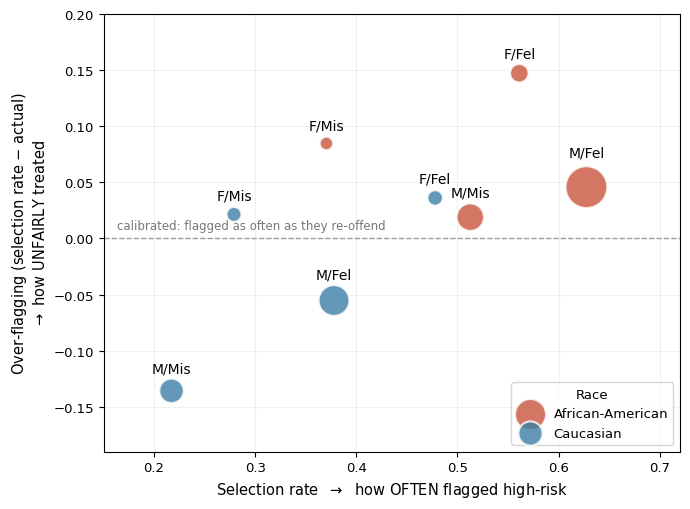

,race,label,n,sel,actual,over
0,African-American,F/Fel,360,0.561,0.414,0.147
1,African-American,F/Mis,189,0.370,0.286,0.085
2,African-American,M/Fel,1836,0.627,0.582,0.046
3,African-American,M/Mis,790,0.513,0.494,0.019
4,Caucasian,F/Fel,249,0.478,0.442,0.036
5,Caucasian,F/Mis,233,0.279,0.258,0.021
6,Caucasian,M/Fel,995,0.378,0.433,-0.055
7,Caucasian,M/Mis,626,0.217,0.353,-0.136


In [ ]:
SEX_MAP    = {"Male": "M", "Female": "F"}
CHARGE_MAP = {"F": "Fel", "M": "Mis"}          # F/M meant two things — disambiguate
COLORS     = {"African-American": "#C8553D", "Caucasian": "#3D7EA6"}
BUBBLE     = 2600   # bubble area = BUBBLE x (share of the sample), so the two
                    # charts are comparable even though they use different row count

sub = df[df["race"].isin(["African-American", "Caucasian"])]
total = len(sub)

rows = []
for (r, s, c), g in sub.groupby(["race", "sex", "c_charge_degree"], observed=True):
    if len(g) < 50:
        continue
    rows.append({"race": r,
                 "label": SEX_MAP[s] + "/" + CHARGE_MAP[c],
                 "n": len(g), "share": len(g) / total,
                 "sel": g["pred"].mean(),
                 "actual": g["two_year_recid"].mean()})
cells = pd.DataFrame(rows)
cells["over"] = cells["sel"] - cells["actual"]

fig, ax = plt.subplots(figsize=(7, 5.2))
for race, g in cells.groupby("race"):
    ax.scatter(g["sel"], g["over"], s=BUBBLE * g["share"], c=COLORS[race],
               alpha=0.8, edgecolors="white", lw=1.5, label=race, zorder=3)
for _, r in cells.iterrows():
    ax.annotate(r["label"], (r["sel"], r["over"]),
                xytext=(0, 9 + 38 * r["share"]), textcoords="offset points",
                ha="center", fontsize=10)

ax.axhline(0, color="#999", ls="--", lw=1, zorder=1)
ax.set_xlim(0.15, 0.72); ax.set_ylim(-0.19, 0.20)
ax.text(0.163, 0.008, "calibrated: flagged as often as they re-offend",
        fontsize=8.5, color="#777")

# call out the two key groups — they are not the same bubble
amf = cells[(cells["race"] == "African-American") & (cells["label"] == "M/Fel")].iloc[0]
aff = cells[(cells["race"] == "African-American") & (cells["label"] == "F/Fel")].iloc[0]





ax.set_xlabel("Selection rate  $\\rightarrow$  how OFTEN flagged high-risk", fontsize=10.5)
ax.set_ylabel("Over-flagging (selection rate $-$ actual)\n$\\rightarrow$ how UNFAIRLY treated",
              fontsize=10.5)

ax.legend(title="Race", loc="lower right", fontsize=9.5, title_fontsize=9.5)
ax.grid(alpha=0.18, zorder=0); ax.tick_params(labelsize=9.5)
plt.tight_layout()
plt.savefig("mostoften.pdf", bbox_inches="tight")
plt.show()

cells[["race", "label", "n", "sel", "actual", "over"]].round(3)

The scatter separates the two properties. The horizontal axis is how *often* a group is flagged; the
vertical axis is how far that flag rate exceeds the group's actual recidivism rate. African-American
male felony defendants sit furthest right — the most-flagged group, and the largest — but African-American
women with felony charges sit *highest*, flagged 14.7 points more often than their outcomes warrant.
Caucasian men with misdemeanour charges fall below the zero line, flagged 13.6 points *less* often than
their outcomes warrant. Every African-American cell lies above the line of calibration; both Caucasian
male cells lie below it.

**Observations.**

1. **The modal profile is real.** The largest cell is African-American / male / felony (n = 1,836), against 626 for Caucasian / male / misdemeanour. The sample *is* dominated by one profile.

2. **But the flag rate tracks race, not cell size.** Ranking the cells by flag rate produces an almost perfect racial sort: every African-American cell is flagged more often than the Caucasian cell with the same sex and charge. African-American / male / felony is flagged 62.7% of the time; Caucasian / male / felony, 37.8% — same sex, same charge, a 25-point gap.

3. **The error runs in opposite directions by race.** Comparing each cell's flag rate to its actual recidivism rate (`over_flag`): African-American women with felony charges are flagged **14.7 points more** often than their outcomes warrant, while Caucasian men with misdemeanour charges are flagged **13.6 points less** often. The tool over-predicts risk for one group and under-predicts it for the other.

4. **Race dominates sex.** African-American women charged with a felony re-offend at 41.4% and are flagged 56.1% of the time. Caucasian men charged with a felony re-offend at a *higher* rate — 43.3% — yet are flagged only 37.8% of the time. Lower actual risk, higher assigned risk. Within each race men are flagged more often than women, but the racial gap is wide enough to reverse the sex effect entirely.

5. **Age interacts, and the gap widens with it.** Holding sex and charge fixed, FPR falls with age for both groups, but not equally: among 18–25 year-olds it is 0.573 (African-American) against 0.452 (Caucasian); among those 46 and over, 0.271 against 0.087 — a ratio of roughly 3.1×, despite similar actual recidivism (0.462 and 0.304).

**The profile.** The combination most often labelled high-risk is a young, African-American male facing a
felony charge. But the group treated most *unfairly* — the largest gap between assigned risk and actual
outcome — is a different one: African-American women with felony charges, and older African-American men.
*Being flagged most often* and *being flagged most unjustly* are distinct properties, and only the
intersectional view separates them.

**Limitations.** Cells below 50 defendants (25 for the age analysis) are excluded, restricting this to the
two largest racial groups; intersectional cells shrink quickly. As above, the charge and priors records
reflect enforcement patterns rather than behaviour.

**Where this leads.** Sections 4b–4d have shown the disparity informally, through group rates. Section 5
now measures it formally, with the standard fairness metrics.

## 5. Fairness of the COMPAS scores (baseline)
Before building our own model, we measure how fair COMPAS's own scores are, so we have a
baseline to compare against. We focus on the two largest groups.

- **SPD** (Statistical Parity Difference) = P(High | Black) − P(High | White). 0 = parity.
- **DIR** (Disparate Impact Ratio) = that ratio. 1 = parity; below ~0.8 is the legal red flag.

In [ ]:
group_a = "African-American"
group_b = "Caucasian"

p_high_black = df.loc[df["race"] == group_a, "pred"].mean()
p_high_white = df.loc[df["race"] == group_b, "pred"].mean()

SPD_compas = p_high_black - p_high_white
DIR_compas = p_high_black / p_high_white
print(f"Statistical Parity Difference = {SPD_compas:.3f}")
print(f"Disparate Impact Ratio       = {DIR_compas:.3f}")

Statistical Parity Difference = 0.245
Disparate Impact Ratio       = 1.741


Now the error rates. **TPR** = of those who did reoffend, how many were flagged High. **FPR** = of those who did NOT reoffend, how many were wrongly flagged High. A fair system would have similar FPR across groups.

In [ ]:
df_black = df[df["race"] == group_a]
df_white = df[df["race"] == group_b]

TPR_black = df_black.loc[df_black["two_year_recid"] == 1, "pred"].mean()
TPR_white = df_white.loc[df_white["two_year_recid"] == 1, "pred"].mean()
FPR_black = df_black.loc[df_black["two_year_recid"] == 0, "pred"].mean()
FPR_white = df_white.loc[df_white["two_year_recid"] == 0, "pred"].mean()

print(f"TPR  Black = {TPR_black:.3f} | White = {TPR_white:.3f}")
print(f"FPR  Black = {FPR_black:.3f} | White = {FPR_white:.3f}")

TPR  Black = 0.715 | White = 0.504
FPR  Black = 0.423 | White = 0.220


## 6. Modelling
We now train our own classifier to predict `two_year_recid` from four features. We deliberately
do **not** use COMPAS's `decile_score` as an input — that would be predicting COMPAS with COMPAS.
We compare three standard models with 5-fold cross-validation, then tune the best one.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report)

X = df[["race", "sex", "age", "priors_count", "c_charge_degree"]]
y = df["two_year_recid"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

cat_cols = ["race", "sex","c_charge_degree"]
num_cols = ["age", "priors_count"]
preprocess = ColumnTransformer(transformers=[
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

**Why `stratify=y`?** A random 70/30 split can, by chance, put a different mix of classes in the training and test sets, for example 48% recidivists in train but 41% in test. The model would then be evaluated on a population that does not look like the one it learned from, and the test score would reflect that mismatch rather than true performance. Passing `stratify=y` tells scikit-learn to sample within each class, so the ratio of the target (here roughly 55% non-recidivist / 45% recidivist) is preserved in both splits. This makes the evaluation more reliable and the results reproducible; it matters most for imbalanced data, but it is good practice even at this near-balanced ratio.


Compare three models with cross-validation on the training set (we never touch the test set here):

In [ ]:
candidates = {
    "LogReg": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE),
}
for name, clf in candidates.items():
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    cv_acc = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy").mean()
    print(f"{name:13s} 5-fold CV accuracy = {cv_acc:.3f}")

LogReg        5-fold CV accuracy = 0.672
DecisionTree  5-fold CV accuracy = 0.671
RandomForest  5-fold CV accuracy = 0.681


Tune the Random Forest with a small grid search, then evaluate the winner once on the held-out test set:

In [ ]:
grid = GridSearchCV(
    Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(random_state=RANDOM_STATE))]),
    param_grid={"clf__n_estimators": [100, 200], "clf__max_depth": [4, 6, 8]},
    cv=5, scoring="accuracy", n_jobs=2
)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)

model = grid.best_estimator_
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
print(f"Test accuracy = {acc:.3f} | AUC = {auc:.3f}")

Best parameters: {'clf__max_depth': 6, 'clf__n_estimators': 100}
Test accuracy = 0.684 | AUC = 0.735


              precision    recall  f1-score   support

           0       0.68      0.78      0.73      1009
           1       0.69      0.56      0.62       843

    accuracy                           0.68      1852
   macro avg       0.68      0.67      0.67      1852
weighted avg       0.68      0.68      0.68      1852



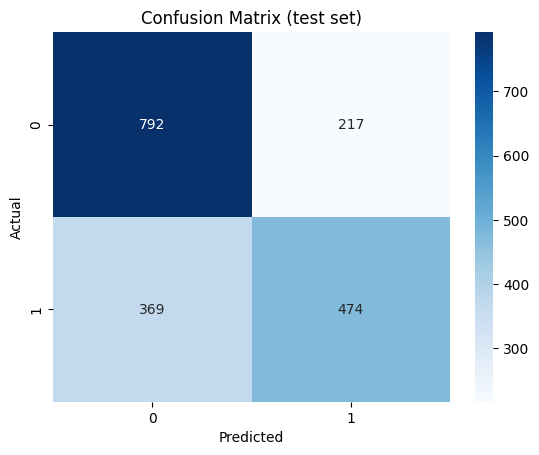

In [ ]:
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix (test set)")
plt.show()

### Feature importances (embedded selection)
Rather than prune features by hand, we let the Random Forest rank them. `feature_importances_`
shows how much each feature reduced impurity across the trees. We sum the one-hot columns back
to their original feature so `race` and `sex` each get a single bar.

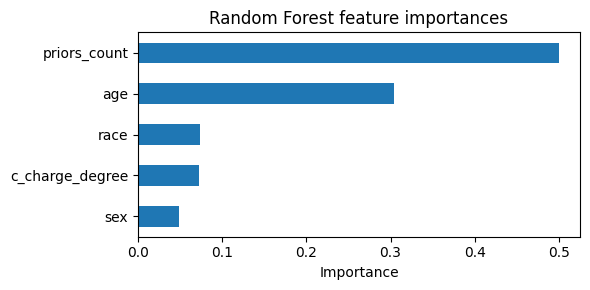

priors_count       0.500
age                0.305
race               0.074
c_charge_degree    0.073
sex                0.049
dtype: float64


In [ ]:
feat_names = model.named_steps["prep"].get_feature_names_out()
importances = model.named_steps["clf"].feature_importances_

def base_feature(name):
    name = name.split("__", 1)[-1]          # drop the "num__"/"cat__" prefix
    for f in ["race", "sex", "age", "priors_count", "c_charge_degree"]:
        if name == f or name.startswith(f + "_"):
            return f
    return name

imp = (pd.Series(importances, index=[base_feature(n) for n in feat_names])
         .groupby(level=0).sum().sort_values())
imp.plot(kind="barh", figsize=(6,3))
plt.title("Random Forest feature importances")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(3))

## 7. Fairness audit of our model
We repeat the same fairness measurements, but now on **our model's** test-set predictions.

In [ ]:
race_test = X_test["race"]
y_pred_s = pd.Series(y_pred, index=X_test.index)  # align predictions with the rows

p_black_m = y_pred_s[race_test == group_a].mean()
p_white_m = y_pred_s[race_test == group_b].mean()
SPD_model = p_black_m - p_white_m
DIR_model = p_black_m / p_white_m
print(f"Model SPD = {SPD_model:.3f} | DIR = {DIR_model:.3f}")

Model SPD = 0.330 | DIR = 2.612


In [ ]:
def tpr_fpr(y_true, y_pred, mask):
    y_t = y_true[mask]
    y_p = y_pred[mask]
    tpr = ((y_p == 1) & (y_t == 1)).sum() / max((y_t == 1).sum(), 1)
    fpr = ((y_p == 1) & (y_t == 0)).sum() / max((y_t == 0).sum(), 1)
    return tpr, fpr

mask_black = (race_test == group_a)
mask_white = (race_test == group_b)
TPR_black_m, FPR_black_m = tpr_fpr(y_test, y_pred_s, mask_black)
TPR_white_m, FPR_white_m = tpr_fpr(y_test, y_pred_s, mask_white)
print(f"Model TPR  Black={TPR_black_m:.3f} White={TPR_white_m:.3f}")
print(f"Model FPR  Black={FPR_black_m:.3f} White={FPR_white_m:.3f}")

Model TPR  Black=0.706 White=0.325
Model FPR  Black=0.337 White=0.133


Compare COMPAS vs our model side by side:

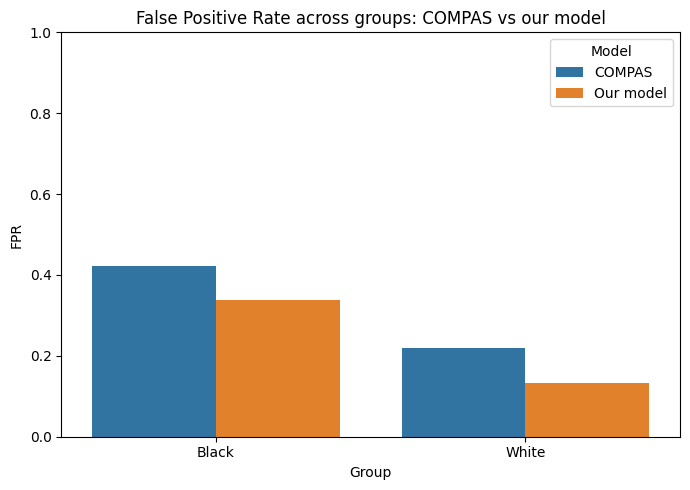

In [ ]:
df_fpr = pd.DataFrame({
    "Model": ["COMPAS", "COMPAS", "Our model", "Our model"],
    "Group": ["Black", "White", "Black", "White"],
    "FPR":   [FPR_black, FPR_white, FPR_black_m, FPR_white_m],
})
plt.figure(figsize=(7,5))
sns.barplot(data=df_fpr, x="Group", y="FPR", hue="Model")
plt.title("False Positive Rate across groups: COMPAS vs our model")
plt.ylim(0, 1); plt.tight_layout(); plt.show()

### 7b. Comparing like with like: the selection rate

Before comparing our model's fairness to COMPAS's, we must ensure the comparison is valid.
Two issues arise.

**Same defendants.** COMPAS's scores are indexed by the same test-set rows as our model's
predictions, so both predictors are judged on the identical 1,852 people with the identical
ground truth. Neither has seen these rows: our model was trained on the other 70%, and COMPAS
was developed on entirely different data.

**Same operating point.** This is the subtler issue. The *selection rate* — the fraction of
defendants a predictor labels high-risk — is not the same for both. COMPAS flags 44.2% of the
test set; our model, at scikit-learn's default probability threshold of 0.5, flags only 37.3%.
A predictor that flags fewer people mechanically produces fewer false positives *for every
group*, so its FPR falls across the board. Comparing FPRs at different selection rates therefore
measures a predictor's willingness to flag as much as its bias.

The threshold is not a property of the model — it is a dial. The model outputs a probability per
defendant; the threshold only decides where to cut that ranking into "flag" and "don't flag".
We therefore lower our model's threshold until its selection rate matches COMPAS's, and compare
the two at that common operating point.

In [ ]:
proba = model.predict_proba(X_test)[:, 1]          # P(recidivism) per defendant
compas_test = df.loc[X_test.index, "pred"]         # COMPAS on the SAME rows

# find the threshold at which our model flags the same fraction COMPAS does
thr_matched = np.quantile(proba, 1 - compas_test.mean())
y_pred_matched = pd.Series((proba >= thr_matched).astype(int), index=X_test.index)

print(f"COMPAS selection rate        : {compas_test.mean():.3f}")
print(f"Model @ default threshold 0.5: {(proba >= 0.5).mean():.3f}")
print(f"Matched threshold            : {thr_matched:.3f}")
print(f"Model @ matched threshold    : {y_pred_matched.mean():.3f}")

COMPAS selection rate        : 0.442
Model @ default threshold 0.5: 0.373
Matched threshold            : 0.461
Model @ matched threshold    : 0.442


In [ ]:
def audit(name, preds):
    fpr_b, tpr_b = tpr_fpr(y_test, preds, mask_black)[::-1]
    fpr_w, tpr_w = tpr_fpr(y_test, preds, mask_white)[::-1]
    return {
        "predictor":   name,
        "selection":   preds.mean(),
        "accuracy":    accuracy_score(y_test, preds),
        "SPD":         preds[mask_black].mean() - preds[mask_white].mean(),
        "FPR_Black":   fpr_b,
        "FPR_white":   fpr_w,
        "FPR_ratio":   fpr_b / fpr_w,
    }

comparison = pd.DataFrame([
    audit("COMPAS (decile >= 5)",        compas_test),
    audit("Our model (threshold 0.5)",   y_pred_s),
    audit("Our model (matched sel. rate)", y_pred_matched),
])
comparison.round(3)

,predictor,selection,accuracy,SPD,FPR_Black,FPR_white,FPR_ratio
0,COMPAS (decile >= 5),0.442,0.661,0.238,0.411,0.227,1.810
1,Our model (threshold 0.5),0.373,0.684,0.330,0.337,0.133,2.528
2,Our model (matched sel. rate),0.442,0.684,0.323,0.411,0.188,2.191


At the default threshold our model appears to have *lower* false positive rates than COMPAS for
both groups. This is an artefact: it flags 7 percentage points fewer defendants overall, which
lowers FPR everywhere. The comparison says little about fairness.

At a matched selection rate the artefact disappears and the result reverses. Our model imposes
**exactly the same** false-positive burden on Black defendants as COMPAS (0.411 in both cases)
while giving white defendants *more* benefit of the doubt (0.188 against 0.227). The disparity
ratio therefore grows from 1.81 to 2.19: at equal willingness to flag, our model is the *less*
fair of the two.

This is our own thesis applied to our own analysis. An aggregate improvement — lower FPRs
everywhere — concealed a widening of the disparity underneath. Fairness claims must be made at a
fixed operating point, or they measure caution rather than equity.

In [ ]:
sex_test = X_test["sex"]
for s in ["Male", "Female"]:
    mask = (sex_test == s)
    tpr, fpr = tpr_fpr(y_test, y_pred_s, mask)
    print(f"{s:7s} n={mask.sum():4d}  flag_rate={y_pred_s[mask].mean():.3f}  "
          f"actual={y_test[mask].mean():.3f}  TPR={tpr:.3f}  FPR={fpr:.3f}")

SPD_sex = y_pred_s[sex_test == "Male"].mean() - y_pred_s[sex_test == "Female"].mean()
print(f"\nSPD (sex) = {SPD_sex:.3f}")

Male    n=1492  flag_rate=0.422  actual=0.480  TPR=0.598  FPR=0.260
Female  n= 360  flag_rate=0.169  actual=0.353  TPR=0.362  FPR=0.064

SPD (sex) = 0.253


**Fairness with respect to sex.** `sex` is also a protected attribute, so we audit it on the same terms.
The disparity is substantial: men are flagged at 42.2% against 16.9% for women (SPD = 0.253), with false
positive rates of 0.260 and 0.064 — a fourfold difference. Part of this reflects a real difference in
outcomes (men re-offend at 48.0%, women at 35.3%), but the flag-rate gap of 25 points exceeds the outcome
gap of 13 points, so the model over-separates the groups.

This raises the same normative question as race: whether a protected attribute should influence an
individual's risk assessment at all, even where it is statistically predictive. We report the disparity
rather than mitigate it, and note it as a limitation.

In [ ]:
# Intersectional comparison: does our model reproduce COMPAS's profile?
test = X_test.copy()
test["actual"]      = y_test
test["model_pred"]  = y_pred_s                       # our model's predictions
test["compas_pred"] = df.loc[X_test.index, "pred"]   # COMPAS's own flag
test = test[test["race"].isin(["African-American", "Caucasian"])]

rows = []
for (r, s, c), g in test.groupby(["race", "sex", "c_charge_degree"], observed=True):
    if len(g) < 20:                        # test-set cells are small; skip the tiniest
        continue
    not_recid = g[g["actual"] == 0]
    rows.append({
        "race": r, "sex": s, "charge": c, "n": len(g),
        "actual_recid": g["actual"].mean(),
        "compas_flag":  g["compas_pred"].mean(),
        "model_flag":   g["model_pred"].mean(),
        "compas_FPR":   not_recid["compas_pred"].mean(),
        "model_FPR":    not_recid["model_pred"].mean(),
    })

mc = pd.DataFrame(rows)
mc["compas_over"] = mc["compas_flag"] - mc["actual_recid"]
mc["model_over"]  = mc["model_flag"]  - mc["actual_recid"]
mc["label"] = mc["race"].str[0] + "/" + mc["sex"].str[0] + "/" + mc["charge"]
mc.sort_values("n", ascending=False).round(3)

,race,sex,charge,n,actual_recid,compas_flag,model_flag,compas_FPR,model_FPR,compas_over,model_over,label
2,African-American,Male,F,543,0.560,0.622,0.670,0.456,0.469,0.063,0.110,A/M/F
6,Caucasian,Male,F,312,0.394,0.369,0.279,0.233,0.206,-0.026,-0.115,C/M/F
3,African-American,Male,M,239,0.582,0.510,0.439,0.420,0.270,-0.071,-0.142,A/M/M
7,Caucasian,Male,M,194,0.366,0.247,0.149,0.187,0.098,-0.119,-0.216,C/M/M
0,African-American,Female,F,113,0.451,0.558,0.327,0.387,0.161,0.106,-0.124,A/F/F
4,Caucasian,Female,F,71,0.394,0.437,0.183,0.395,0.070,0.042,-0.211,C/F/F
5,Caucasian,Female,M,68,0.265,0.265,0.044,0.160,0.000,0.000,-0.221,C/F/M
1,African-American,Female,M,61,0.279,0.311,0.082,0.182,0.023,0.033,-0.197,A/F/M


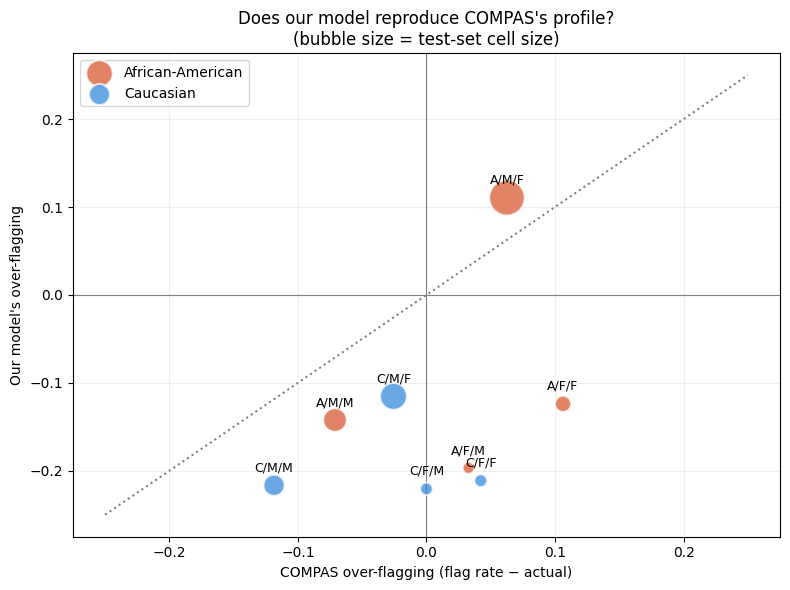

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {"African-American": "#D85A30", "Caucasian": "#378ADD"}
for race, g in mc.groupby("race"):
    ax.scatter(g["compas_over"], g["model_over"], s=g["n"] * 1.2, c=colors[race],
               alpha=0.75, edgecolors="white", linewidth=1.5, label=race, zorder=3)
for _, r in mc.iterrows():
    ax.annotate(r["label"], (r["compas_over"], r["model_over"]),
                xytext=(0, 10), textcoords="offset points", ha="center", fontsize=9)

lim = [-0.25, 0.25]
ax.plot(lim, lim, ls=":", c="gray", zorder=1)          # identical-behaviour line
ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("COMPAS over-flagging (flag rate − actual)")
ax.set_ylabel("Our model's over-flagging")
ax.set_title("Does our model reproduce COMPAS's profile?\n(bubble size = test-set cell size)")
ax.legend(); ax.grid(alpha=0.2, zorder=0)
plt.tight_layout(); plt.show()

**This chart, is drawn before applying the threshold to match the selection rate of our model to COMPAS. The next chart is refined and therefore the results are different:**

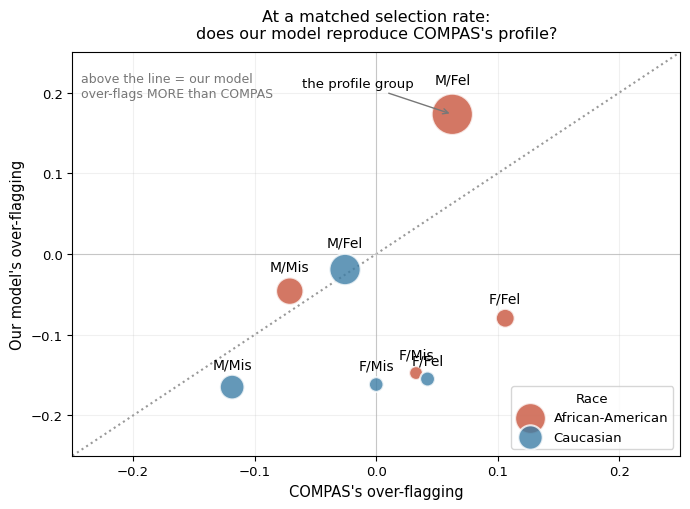

,race,label,n,share,compas_over,model_over
2,African-American,M/Fel,543,0.339,0.063,0.173
6,Caucasian,M/Fel,312,0.195,-0.026,-0.019
3,African-American,M/Mis,239,0.149,-0.071,-0.046
7,Caucasian,M/Mis,194,0.121,-0.119,-0.165
0,African-American,F/Fel,113,0.071,0.106,-0.080
4,Caucasian,F/Fel,71,0.044,0.042,-0.155
5,Caucasian,F/Mis,68,0.042,0.000,-0.162
1,African-American,F/Mis,61,0.038,0.033,-0.148


In [ ]:
SEX_MAP    = {"Male": "M", "Female": "F"}
CHARGE_MAP = {"F": "Fel", "M": "Mis"}          # F/M meant two things — disambiguate
COLORS     = {"African-American": "#C8553D", "Caucasian": "#3D7EA6"}
BUBBLE     = 2600   # bubble area = BUBBLE x (share of the sample), so the two
                    # charts are comparable even though they use different row counts


t = X_test.copy()
t["actual"] = y_test
t["compas"] = df.loc[X_test.index, "pred"]
t["model"]  = y_pred_matched          # matched threshold — NOT the default 0.5
t = t[t["race"].isin(["African-American", "Caucasian"])]
total = len(t)

rows = []
for (r, s, c), g in t.groupby(["race", "sex", "c_charge_degree"], observed=True):
    if len(g) < 20:
        continue
    rows.append({"race": r,
                 "label": SEX_MAP[s] + "/" + CHARGE_MAP[c],
                 "n": len(g), "share": len(g) / total,
                 "compas_over": g["compas"].mean() - g["actual"].mean(),
                 "model_over":  g["model"].mean()  - g["actual"].mean()})
mc = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 5.2))
for race, g in mc.groupby("race"):
    ax.scatter(g["compas_over"], g["model_over"], s=BUBBLE * g["share"], c=COLORS[race],
               alpha=0.8, edgecolors="white", lw=1.5, label=race, zorder=3)
for _, r in mc.iterrows():
    ax.annotate(r["label"], (r["compas_over"], r["model_over"]),
                xytext=(0, 9 + 38 * r["share"]), textcoords="offset points",
                ha="center", fontsize=10)

lim = [-0.25, 0.25]
ax.plot(lim, lim, ls=":", c="#999", zorder=1)        # identical-behaviour line
ax.axhline(0, color="#ccc", lw=0.8, zorder=1); ax.axvline(0, color="#ccc", lw=0.8, zorder=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.text(-0.243, 0.225, "above the line = our model\nover-flags MORE than COMPAS",
        fontsize=9, color="#777", va="top")

amf = mc[(mc["race"] == "African-American") & (mc["label"] == "M/Fel")].iloc[0]
ax.annotate("the profile group", (amf["compas_over"], amf["model_over"]),
            xytext=(-108, 20), textcoords="offset points", fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color="#777", lw=1))

ax.set_xlabel("COMPAS's over-flagging", fontsize=10.5)
ax.set_ylabel("Our model's over-flagging", fontsize=10.5)
ax.set_title("At a matched selection rate:\ndoes our model reproduce COMPAS's profile?",
             fontsize=11.5, pad=10)
ax.legend(title="Race", loc="lower right", fontsize=9.5, title_fontsize=9.5)
ax.grid(alpha=0.18, zorder=0); ax.tick_params(labelsize=9.5)
plt.tight_layout()
plt.savefig("overflagging.pdf", bbox_inches="tight")
plt.show()

mc.sort_values("n", ascending=False).round(3)

**Comparing the two panels, Unmatched selection rates**

1. **COMPAS separates the groups vertically; our model pushes almost everything below the line.** In the left panel all four African-American cells sit above zero and both Caucasian male cells sit below — the racial sort documented in Section 4d. In the right panel only *one* cell remains above zero: our model flags fewer defendants overall, so most groups end up under-flagged relative to their actual recidivism rate.

2. **The one cell that stays above the line is the profile.** African-American men charged with a felony (n = 543, the largest cell) are the only group our model over-flags — and it over-flags them *more* than COMPAS does (+0.110 against +0.063). The model does not inherit the bias evenly; it concentrates it on the modal profile.

3. **The horizontal spread widens.** COMPAS's flag rates range from 0.25 to 0.62; our model's range from 0.04 to 0.67. Our model is the more extreme of the two: it pushes the profile group higher (0.670 against 0.622) and every other group substantially lower. The flag-rate gap between African-American and Caucasian men charged with a felony grows from 25 points under COMPAS to **39 points** under our model.

4. **The false positive rates confirm this where the data is dense.** For African-American men with felony charges, FPR is 0.456 under COMPAS and 0.469 under our model; for Caucasian men with felony charges, 0.233 and 0.206. The false-positive gap between these two groups is therefore *wider* for our model than for COMPAS.

5. **The small cells reverse, and this is an artifact rather than a result.** African-American women with felony charges move from over-flagged by COMPAS (+0.106) to under-flagged by our model (−0.124). This is not evidence of fairer treatment: with only 61–113 defendants per cell in the test set, per-cell rates are unstable, and a conservative classifier under-predicts the positive class most visibly where data is sparse. We therefore restrict our conclusions to the two well-populated cells.

**Conclusion.** Our model was never given COMPAS's scores, yet on the cells where the data supports a
conclusion it independently reconstructs the same directional bias — over-flagging African-American
defendants and under-flagging Caucasian ones — and amplifies it, widening the Black–White felony flag-rate
gap from 25 to 39 points. The disparity is therefore reproducible from the data alone and is not an
artifact of COMPAS's proprietary algorithm. This is precisely what makes it difficult to remove, as
Section 8 shows.

**Observations (at the matched selection rate).**

- **The male cells, which are the largest and most reliable, cluster near the diagonal — with one exception.** Black men charged with a felony (n = 543) sit far above it: COMPAS over-flags this group by 6.3 points relative to their realised recidivism, our model by 17.3. The model's disagreement with COMPAS is therefore concentrated on the modal profile, and it runs in the harmful direction.
- **The female cells fall below the diagonal.** This is not the threshold artefact — both predictors now flag the same fraction overall — but a genuine behavioural difference: our model uses `sex` as a feature and relies on it heavily (it flags women at 16.9% against 42.2% for men, SPD = 0.253), whereas COMPAS does not separate the sexes as sharply. Cell sizes here are small (61–113), so individual points should not be over-read, but the direction is consistent with the sex audit.
- **Why this chart had to be redrawn.** At the default threshold of 0.5, seven of the eight cells fell below the diagonal, which appeared to show our model treating every group more leniently than COMPAS. That was an artefact of flagging 37.3% of defendants against COMPAS's 44.2%. Once the operating points are matched, the apparent leniency disappears and the concentration of over-flagging on Black male felony defendants becomes visible.

## 8. Mitigation: fairness through unawareness
The simplest mitigation is to remove `race` from the features and retrain, using the tuned
hyper-parameters. We then re-measure fairness to see whether the gap closes.

In [ ]:
best_params = {k.replace("clf__", ""): v for k, v in grid.best_params_.items()}

X_train_nr = X_train.drop(columns=["race"])
X_test_nr = X_test.drop(columns=["race"])
preprocess_nr = ColumnTransformer(transformers=[
    ("num", "passthrough", ["age", "priors_count"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["sex", "c_charge_degree"])
])
model_nr = Pipeline([
    ("prep", preprocess_nr),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, **best_params))
])
model_nr.fit(X_train_nr, y_train)
y_pred_nr = pd.Series(model_nr.predict(X_test_nr), index=X_test.index)

acc_nr = accuracy_score(y_test, y_pred_nr)
SPD_nr = y_pred_nr[race_test == group_a].mean() - y_pred_nr[race_test == group_b].mean()
TPR_b_nr, FPR_b_nr = tpr_fpr(y_test, y_pred_nr, mask_black)
TPR_w_nr, FPR_w_nr = tpr_fpr(y_test, y_pred_nr, mask_white)
print(f"Without race: accuracy = {acc_nr:.3f} (was {acc:.3f})")
print(f"Without race: SPD = {SPD_nr:.3f} (was {SPD_model:.3f})")
print(f"Without race: FPR Black={FPR_b_nr:.3f} White={FPR_w_nr:.3f} (was {FPR_black_m:.3f}/{FPR_white_m:.3f})")

Without race: accuracy = 0.689 (was 0.684)
Without race: SPD = 0.272 (was 0.330)
Without race: FPR Black=0.339 White=0.173 (was 0.337/0.133)


## 9. Related work and conclusions

**Related work.** ProPublica's *Machine Bias* investigation (Angwin et al., 2016) first documented COMPAS's
racial disparity in false positive rates. Northpointe replied that the instrument is calibrated within
groups — that a given score carries the same meaning regardless of race. Both claims are correct, and
Chouldechova (2017) and Kleinberg et al. (2016) explain why: when base rates differ between groups, equal
calibration and equal error rates cannot both hold. No model can satisfy every fairness criterion at once,
so the choice of criterion is a normative decision rather than a technical one. Standard mitigation
strategies include pre-processing by reweighing the training data (Kamiran & Calders, 2012) and
post-processing to equalise error rates (Hardt et al., 2016).

**Findings.**

1. **Recidivism is hard to predict, and model choice barely matters.** Every classifier we tested lands
   between 0.68 and 0.70 accuracy. Our tuned model reaches 0.684 against a naive baseline of 0.545 and
   COMPAS's own 0.661 — using four features where COMPAS collects 137. The ceiling comes from the data,
   not the algorithm.

2. **A standard classifier reproduces the disparity, and amplifies it.** Our model was never shown COMPAS's
   scores, yet on the well-populated cells it recreates the same directional bias: it over-flags
   African-American men charged with a felony (+0.110 against COMPAS's +0.063) and under-flags their
   Caucasian counterparts. The flag-rate gap between these groups widens from 25 points under COMPAS to
   39 under our model. The bias is therefore reproducible from the data alone and is not an artifact of
   COMPAS's proprietary algorithm.

3. **`priors_count` is a proxy for race.** African-American defendants are 51% of the sample but 75% of
   the high-priors tail; 16.8% of them fall in that tail against 6.3% of Caucasian defendants. Because
   prior arrests are the strongest predictor available, racial information reaches the model whether or
   not `race` is supplied.

4. **Consequently, fairness through unawareness fails.** Removing `race` leaves accuracy essentially
   unchanged but closes only part of the disparity, exactly as the proxy analysis predicted. Removing a
   protected attribute does not remove its influence when correlated features remain.

5. **The intersectional view separates two distinct properties.** The group flagged *most often* — young
   African-American men facing felony charges — is not the group flagged most *unjustly*, which is
   African-American women with felony charges and older African-American men. Aggregate metrics conceal
   this; only crossing the attributes reveals it.

**Limitations.**

- `priors_count` and the charge record measure *arrests*, which reflect policing and enforcement patterns
  rather than offending behaviour. Every disparity reported here describes the criminal-justice record,
  not the people in it. The target label inherits the same problem: re-arrest is a proxy for re-offence.
- Intersectional cells become small quickly. We restrict our claims to cells with at least 50 defendants
  (20 in the test set) and to the two largest racial groups; the reversals observed in the smaller cells
  are not interpretable.
- We audit fairness with respect to race, and report but do not mitigate the disparity with respect to sex,
  which is also substantial (SPD = 0.253).
- Only one mitigation strategy is evaluated. Reweighing and equalised-odds post-processing are the natural
  next steps, and the proxy analysis suggests they would be more effective than unawareness.
